In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import scipy.io as sio
from joblib import Parallel, delayed

import sys
import os
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)
    
from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [12]:
labels = ["Low Coherence", "High Coherence", "Divided Attention", "Focused Attention", "Unexpected", "Expected"]
colors = ["gray", "darkgray", "blue", "darkblue", "red", "darkred"]
linestyles = ["--", "-", "--", "-", "--", "-"]

xaxis = np.array(range(-250, 750, 1))*(1000/120)

In [13]:
# Masks
low_coherence_mask = r_table["coh"] == -1
high_coherence_mask = r_table["coh"] == 1

divided_attention_mask = r_table["att"] == -1
focused_attention_mask = r_table["att"] == 1

unexpected_mask = r_table["exp_al"] == 0
expected_mask = r_table["exp_al"] == 1

/tmp/ipykernel_19804/2279973612.py:11: RuntimeWarning: Mean of empty slice
  e_low = np.nanmean(e.reshape(-1, 1000)[low_coherence_mask], axis=0)
/tmp/ipykernel_19804/2279973612.py:12: RuntimeWarning: Mean of empty slice
  e_high = np.nanmean(e.reshape(-1, 1000)[high_coherence_mask], axis=0)
/tmp/ipykernel_19804/2279973612.py:14: RuntimeWarning: Mean of empty slice
  e_divided = np.nanmean(e.reshape(-1, 1000)[divided_attention_mask], axis=0)
/tmp/ipykernel_19804/2279973612.py:15: RuntimeWarning: Mean of empty slice
  e_focused = np.nanmean(e.reshape(-1, 1000)[focused_attention_mask], axis=0)
/tmp/ipykernel_19804/2279973612.py:17: RuntimeWarning: Mean of empty slice
  e_unexpected = np.nanmean(e.reshape(-1, 1000)[unexpected_mask], axis=0)
/tmp/ipykernel_19804/2279973612.py:18: RuntimeWarning: Mean of empty slice
  e_expected = np.nanmean(e.reshape(-1, 1000)[expected_mask], axis=0)


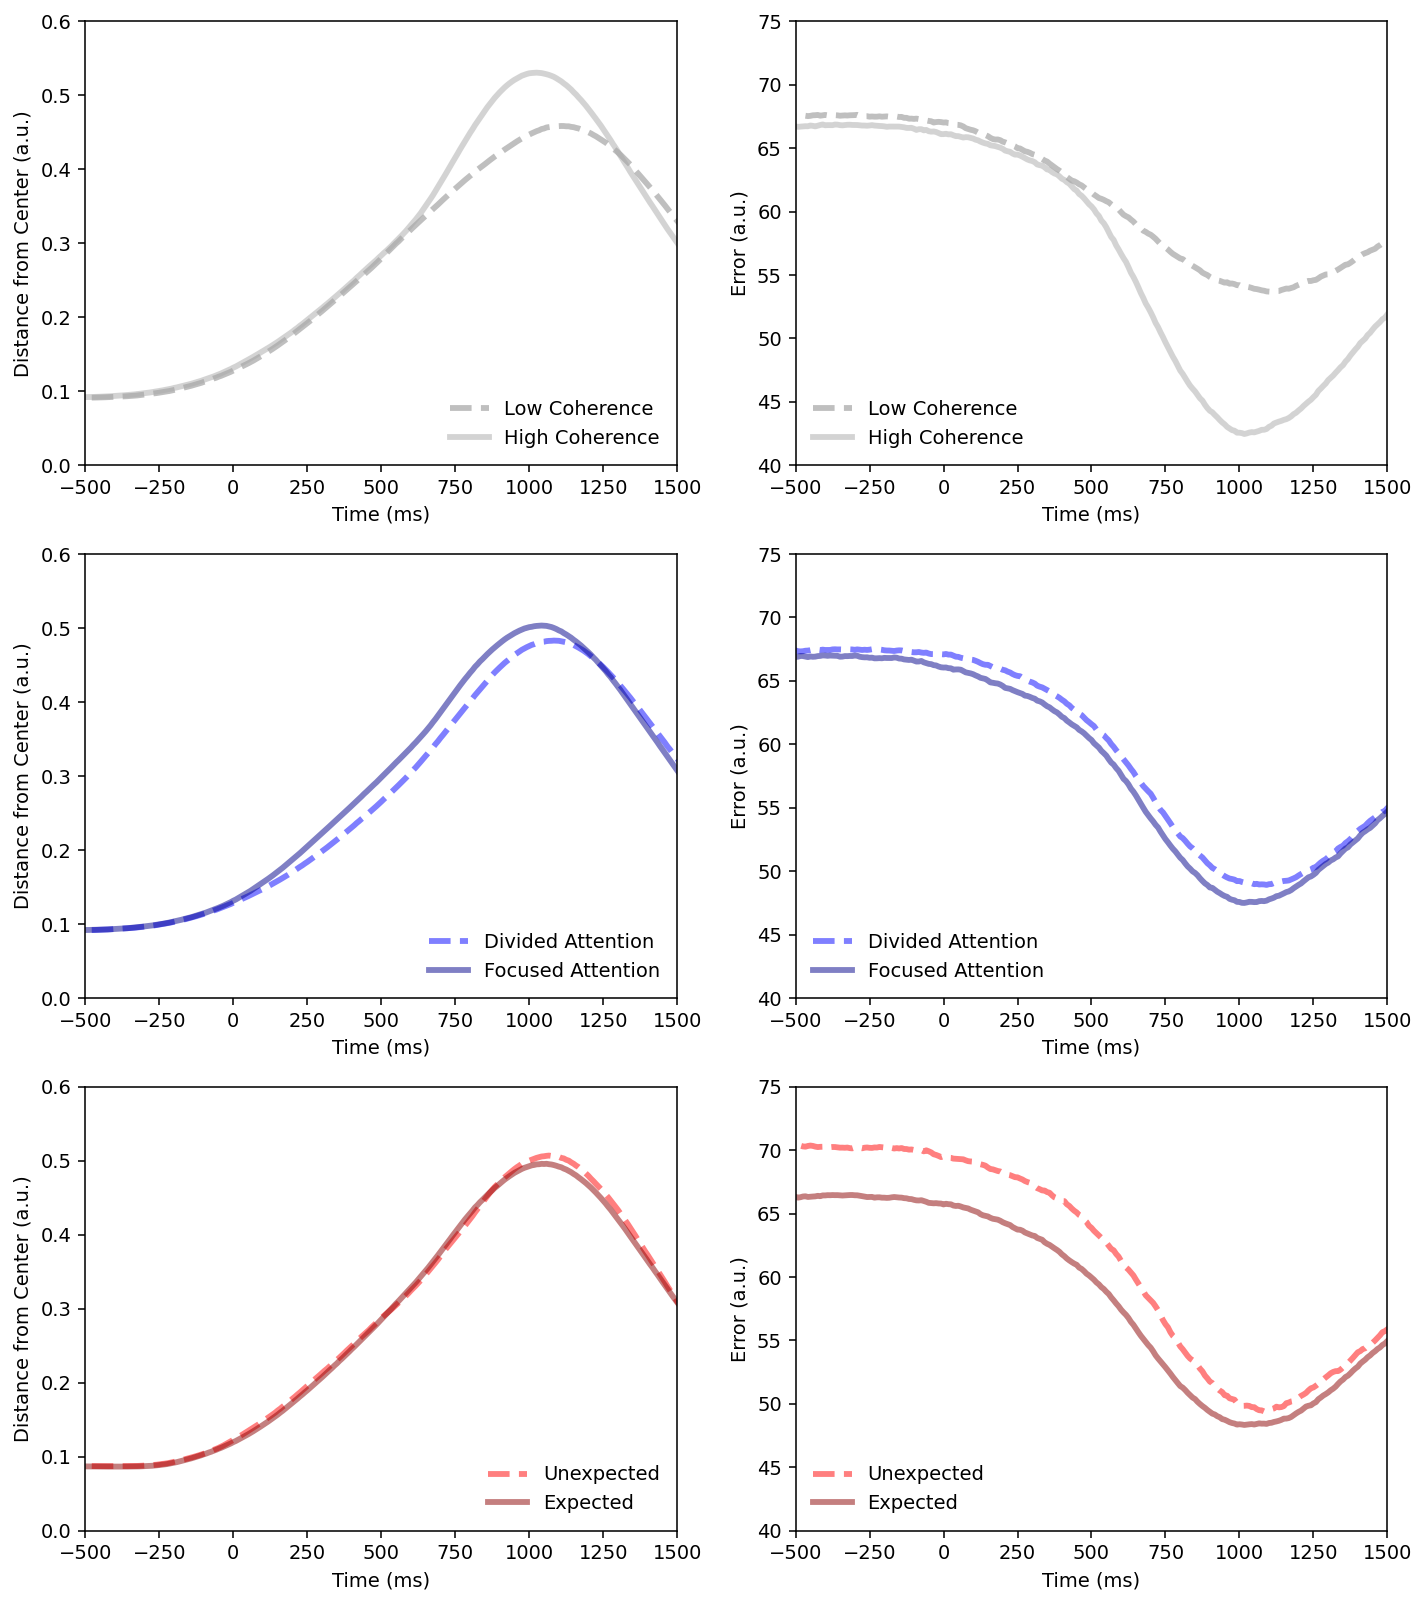

In [14]:
d_low = d.reshape(-1, 1000)[low_coherence_mask].mean(axis=0)
d_high = d.reshape(-1, 1000)[high_coherence_mask].mean(axis=0)

d_divided = d.reshape(-1, 1000)[divided_attention_mask].mean(axis=0)
d_focused = d.reshape(-1, 1000)[focused_attention_mask].mean(axis=0)

d_unexpected = d.reshape(-1, 1000)[unexpected_mask].mean(axis=0)
d_expected = d.reshape(-1, 1000)[expected_mask].mean(axis=0)


e_low = np.nanmean(e.reshape(-1, 1000)[low_coherence_mask], axis=0)
e_high = np.nanmean(e.reshape(-1, 1000)[high_coherence_mask], axis=0)

e_divided = np.nanmean(e.reshape(-1, 1000)[divided_attention_mask], axis=0)
e_focused = np.nanmean(e.reshape(-1, 1000)[focused_attention_mask], axis=0)

e_unexpected = np.nanmean(e.reshape(-1, 1000)[unexpected_mask], axis=0)
e_expected = np.nanmean(e.reshape(-1, 1000)[expected_mask], axis=0)

# Plotting the data
fig, ax = plt.subplots(3,2, figsize=(6*2, 14))

d_ax = ax[:,0]
e_ax = ax[:,1]

vals = [d_low, d_high, d_divided, d_focused, d_unexpected, d_expected]

for i in range(6):
    d_ax[i//2].plot(xaxis, vals[i], linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=3)
    d_ax[i//2].set_xlim(-500, 1500)
    d_ax[i//2].set_ylim(0, 0.6)
    d_ax[i//2].legend( loc='lower right', frameon=False)
    d_ax[i//2].set_xlabel("Time (ms)")
    d_ax[i//2].set_ylabel("Distance from Center (a.u.)")


vals = [e_low, e_high, e_divided, e_focused, e_unexpected, e_expected]

for i in range(6):
    e_ax[i//2].plot(xaxis, vals[i], linestyle=linestyles[i], label=labels[i], color=colors[i], alpha=0.5, linewidth=3)
    e_ax[i//2].set_xlim(-500, 1500)
    e_ax[i//2].set_ylim(40, 75)
    e_ax[i//2].legend( loc='lower left', frameon=False)
    e_ax[i//2].set_xlabel("Time (ms)")
    e_ax[i//2].set_ylabel("Error (a.u.)")


In [15]:
# Raw data arrays (each trial x timepoints)
d_data = d.reshape(-1, 1000)
e_data = e.reshape(-1, 1000)

# For d:
d_low_trials      = d_data[low_coherence_mask]
d_high_trials     = d_data[high_coherence_mask]
d_divided_trials  = d_data[divided_attention_mask]
d_focused_trials  = d_data[focused_attention_mask]
d_unexpected_trials = d_data[unexpected_mask]
d_expected_trials   = d_data[expected_mask]

# For e:
e_low_trials      = e_data[low_coherence_mask]
e_high_trials     = e_data[high_coherence_mask]
e_divided_trials  = e_data[divided_attention_mask]
e_focused_trials  = e_data[focused_attention_mask]
e_unexpected_trials = e_data[unexpected_mask]
e_expected_trials   = e_data[expected_mask]


(-500.0, 1500.0)

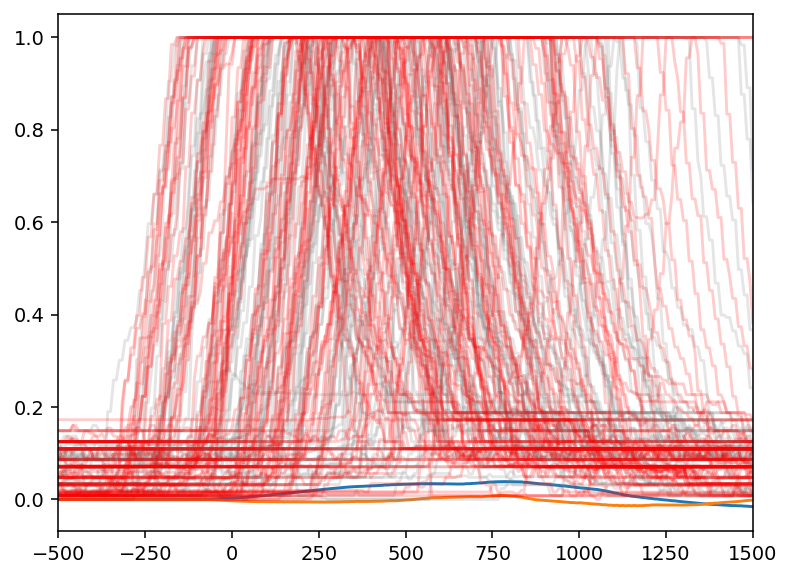

In [24]:
plt.plot(xaxis, d_focused - d_divided)
plt.plot(xaxis, d_expected - d_unexpected)
for line in d_expected_trials[:100]:
    plt.plot(xaxis, line, color="gray", alpha=0.2)
for line in d_unexpected_trials[:100]:
    plt.plot(xaxis, line, color="red", alpha=0.2)
    

plt.xlim(-500, 1500)

In [7]:
# d_high_ci, d_low_ci, high_low_ci 

In [10]:
nboot = 1000
CI_int = (2.5, 97.5)
random_seed = 42

# d differences:
# Coherence: high vs. low
_, _, diff_CI_coh, _ = fnc_time_bootstrap_optimized(
    d_high_trials, d_low_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Attention: focused vs. divided
_, _, diff_CI_att, _ = fnc_time_bootstrap_optimized(
    d_focused_trials, d_divided_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
# Expectation: expected vs. unexpected
_, _, diff_CI_exp, _ = fnc_time_bootstrap_optimized(
    d_expected_trials, d_unexpected_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)

# # e differences:
_, _, diff_CI_coh_e, _ = fnc_time_bootstrap_optimized(
    e_high_trials, e_low_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_att_e, _ = fnc_time_bootstrap_optimized(
    e_focused_trials, e_divided_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)
_, _, diff_CI_exp_e, _ = fnc_time_bootstrap_optimized(
    e_expected_trials, e_unexpected_trials, nboot, CI_int, n_jobs=-1, random_seed=random_seed)


/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:48: RuntimeWarning: Mean of empty slice
  t2_avg = np.nanmean(t2_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/utils/bootstrap.py:47: RuntimeWarning: Mean of empty slice
  t1_avg = np.nanmean(t1_resampled, axis=1)
/home/nuttidalab/Documents/rudra/state_space_analysis/util

KeyboardInterrupt: 

NameError: name 'diff_CI_coh' is not defined

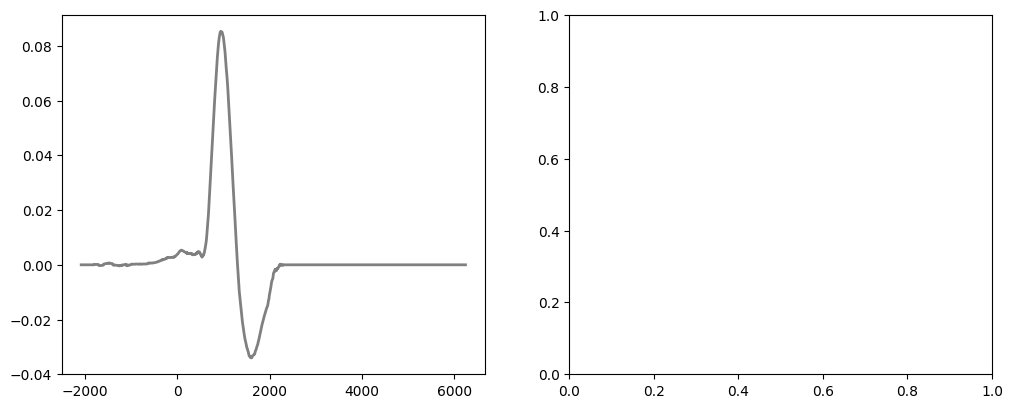

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 14/3), dpi=100)

alpha = 0.5

# Plot d differences:
axs[0].plot(xaxis, d_high - d_low, label='High - Low', color='gray', linewidth=2)
axs[0].fill_between(xaxis, diff_CI_coh[:, 0], diff_CI_coh[:, 1], color='gray', alpha=alpha)
axs[0].plot(xaxis, d_focused - d_divided, label='Focused - Divided', color='blue', linewidth=2)
axs[0].fill_between(xaxis, diff_CI_att[:, 0], diff_CI_att[:, 1], color='blue', alpha=alpha)
axs[0].plot(xaxis, d_expected - d_unexpected, label='Expected - Unexpected', color='red', linewidth=2)
axs[0].fill_between(xaxis, diff_CI_exp[:, 0], diff_CI_exp[:, 1], color='red', alpha=alpha)
axs[0].set_title('Differences in d')
axs[0].set_xlim(-500, 1500)
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('High - Low')
axs[0].legend( loc='lower right', frameon=False)

# Plot e differences:
axs[1].plot(xaxis, diff_avg_coh_e, label='High - Low', color='gray', linewidth=2)
axs[1].fill_between(xaxis, diff_CI_coh_e[:, 0], diff_CI_coh_e[:, 1], color='lightgray', alpha=alpha)
axs[1].plot(xaxis, diff_avg_att_e, label='Focused - Divided', color='blue', linewidth=2)
axs[1].fill_between(xaxis, diff_CI_att_e[:, 0], diff_CI_att_e[:, 1], color='lightblue', alpha=alpha)
axs[1].plot(xaxis, diff_avg_exp_e, label='Expected - Unexpected', color='red', linewidth=2)
axs[1].fill_between(xaxis, diff_CI_exp_e[:, 0], diff_CI_exp_e[:, 1], color='lightred', alpha=alpha)
axs[1].set_title('Differences in e')
axs[1].set_xlim(-500, 1500)
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('High - Low')
axs[1].legend( loc='lower left', frameon=False)

# plt.tight_layout()
plt.show()
